In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

plt.style.use('default')

In [11]:
listings = pd.read_csv(
    "../data/processed/listings_clean.csv",
    parse_dates=['first_review', 'last_review']
)

calendar = pd.read_csv(
    "../data/processed/calendar_clean.csv",
    parse_dates=['date']
)

reviews = pd.read_csv(
    "../data/processed/reviews_clean.csv",
    parse_dates=['date']
)

neighborhood_summary = pd.read_csv(
    "../data/processed/neighborhood_summary.csv"
)

In [12]:
print(listings.shape)
print(calendar.shape)
print(reviews.shape)

(453, 44)
(165345, 5)
(27884, 6)


In [13]:
listings.describe()

,listing_id,host_id,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,estimated_occupancy_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,first_review,last_review,calculated_host_listings_count,occupancy_rate,amenities_count,availability_ratio,estimated_occupancy_from_calendar
count,4.530000e+02,4.530000e+02,453.000000,453.000000,453.000000,437.000000,450.000000,437.00000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395,395,453.000000,453.000000,453.000000,453.000000,453.000000
mean,8.981917e+17,2.505305e+08,42.659237,-73.776699,3.439294,1.231121,1.597778,1.82151,5.825607,631.823400,18.150110,40.211921,63.326711,258.172185,61.571744,13.865342,0.704194,79.620309,4.733291,4.771139,4.749671,4.829342,4.838759,4.633924,4.692835,1.840684,2023-04-02 03:31:26.582278,2025-10-10 12:56:30.379746,7.662252,0.218138,37.379691,0.707321,0.292679
min,2.992450e+06,6.490680e+05,42.630660,-73.876490,1.000000,0.000000,0.000000,0.00000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.500000,2.330000,2.330000,2.500000,1.000000,2.000000,2.500000,0.030000,2014-07-01 00:00:00,2022-08-17 00:00:00,1.000000,0.000000,6.000000,0.000000,0.000000
25%,5.932721e+17,4.762598e+07,42.652620,-73.787714,2.000000,1.000000,1.000000,1.00000,1.000000,365.000000,11.000000,26.000000,46.000000,175.000000,3.000000,1.000000,0.000000,6.000000,4.670000,4.750000,4.685000,4.810000,4.840000,4.500000,4.630000,0.425000,2022-01-05 12:00:00,2025-09-29 12:00:00,1.000000,0.016438,25.000000,0.479452,0.021918
50%,1.020519e+18,2.329679e+08,42.657620,-73.774560,2.000000,1.000000,1.000000,1.00000,1.000000,365.000000,22.000000,48.000000,76.000000,307.000000,18.000000,6.000000,0.000000,54.000000,4.850000,4.900000,4.870000,4.940000,4.950000,4.790000,4.810000,1.230000,2023-11-03 00:00:00,2025-12-21 00:00:00,5.000000,0.147945,39.000000,0.841096,0.158904
75%,1.383911e+18,4.330961e+08,42.666120,-73.763820,4.000000,1.000000,2.000000,2.00000,3.000000,1125.000000,27.000000,57.000000,87.000000,357.000000,68.000000,18.000000,1.000000,126.000000,4.970000,4.980000,4.980000,5.000000,5.000000,4.930000,4.930000,2.575000,2025-05-01 12:00:00,2026-01-28 00:00:00,11.000000,0.345205,47.000000,0.978082,0.520548
max,1.611096e+18,7.395856e+08,42.714900,-73.738250,16.000000,7.000000,9.000000,10.00000,180.000000,1125.000000,30.000000,60.000000,90.000000,365.000000,972.000000,127.000000,9.000000,255.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,10.440000,2026-01-31 00:00:00,2026-02-14 00:00:00,30.000000,0.698630,84.000000,1.000000,1.000000
std,5.701275e+17,2.013526e+08,0.010570,0.018555,2.436622,0.639231,1.171485,1.32381,14.542524,428.346775,10.458704,20.146678,28.941031,115.813576,114.667091,19.267722,1.363528,84.195552,0.382619,0.378788,0.368865,0.329483,0.364384,0.451638,0.403480,1.888654,NaN,NaN,7.994650,0.230673,15.239583,0.317297,0.317297


In [14]:
neighborhood_counts = (
    listings['neighborhood']
    .value_counts()
    .sort_values(ascending=False)
)

neighborhood_counts

neighborhood
Sixth Ward         106
Tenth Ward          49
Second Ward         43
Thirteenth Ward     39
Ninth Ward          36
Third Ward          33
Eleventh Ward       30
Fourteenth Ward     29
Fifth Ward          19
Fourth Ward         17
Fifteenth Ward      15
Seventh Ward        13
Eighth Ward         12
First Ward           9
Twelfth Ward         3
Name: count, dtype: int64

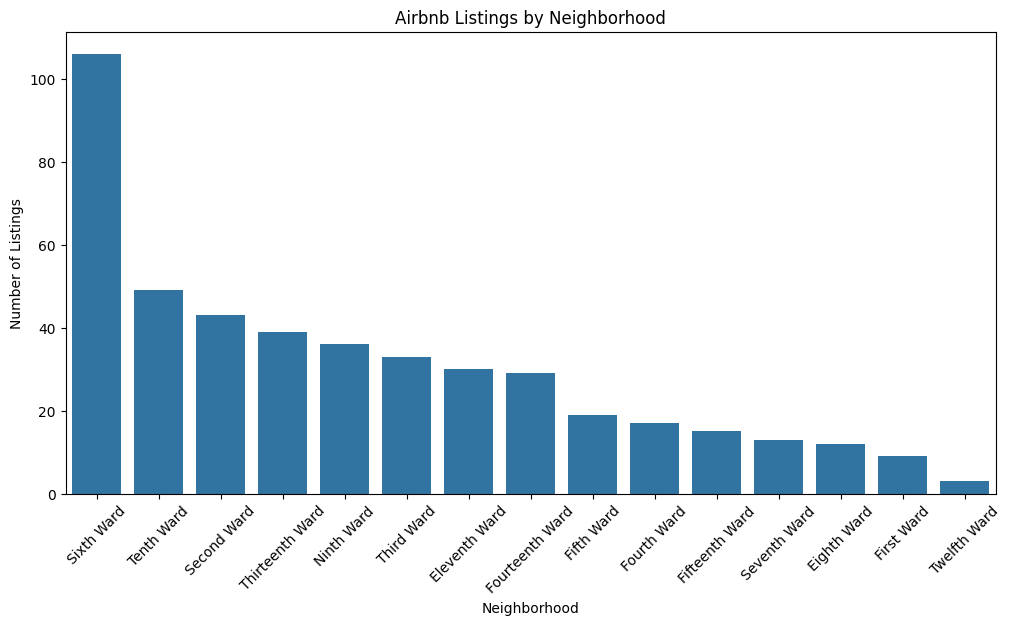

In [15]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=neighborhood_counts.index,
    y=neighborhood_counts.values
)

plt.xticks(rotation=45)

plt.title("Airbnb Listings by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Number of Listings")

plt.show()

In [16]:
neighborhood_occupancy = (
    listings
    .groupby('neighborhood')['occupancy_rate']
    .mean()
    .sort_values(ascending=False)
)

neighborhood_occupancy

neighborhood
Fourteenth Ward    0.346623
Second Ward        0.334820
Fifteenth Ward     0.330594
Sixth Ward         0.249418
First Ward         0.234703
Eighth Ward        0.229909
Thirteenth Ward    0.229153
Seventh Ward       0.226344
Ninth Ward         0.161111
Fourth Ward        0.155197
Eleventh Ward      0.152694
Tenth Ward         0.144590
Third Ward         0.133001
Fifth Ward         0.084787
Twelfth Ward       0.038356
Name: occupancy_rate, dtype: float64

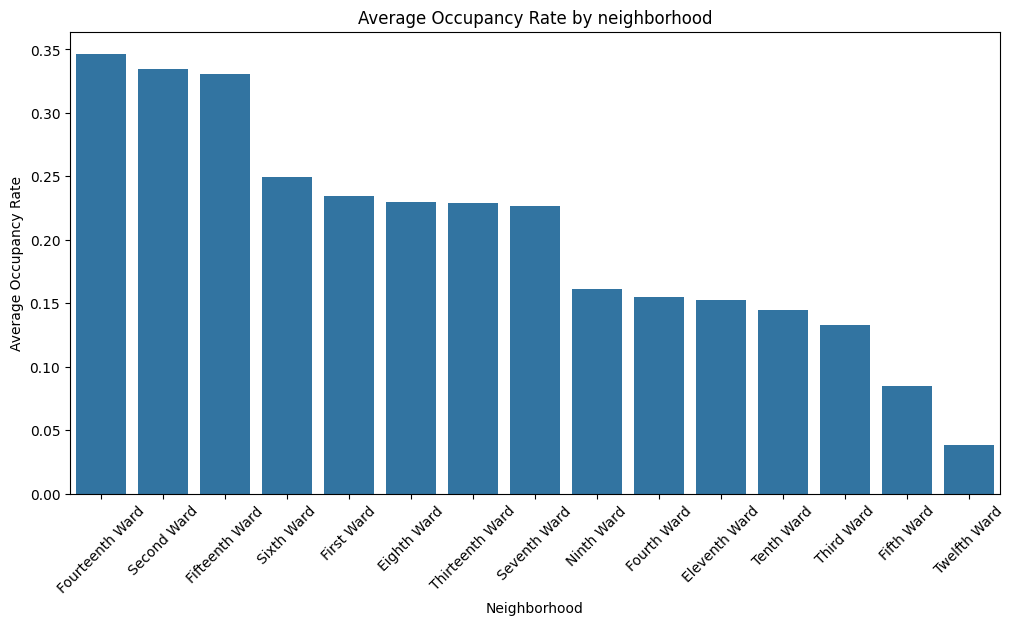

In [17]:
plt.figure(figsize=(12,6))

sns.barplot(x= neighborhood_occupancy.index,y = neighborhood_occupancy.values)

plt.xticks(rotation=45)
plt.title("Average Occupancy Rate by neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Average Occupancy Rate")
plt.show()

In [18]:
# ratings by neighborhood
ratings_by_neighborhood = (
    listings.groupby('neighborhood')['review_scores_rating']
    .mean().sort_values(ascending=False)
)

ratings_by_neighborhood

neighborhood
Eighth Ward        4.942857
Fourteenth Ward    4.912143
Fifteenth Ward     4.911333
Twelfth Ward       4.893333
Thirteenth Ward    4.835946
Ninth Ward         4.783125
Tenth Ward         4.771750
Seventh Ward       4.738333
Sixth Ward         4.733667
Second Ward        4.733333
First Ward         4.692500
Fourth Ward        4.655333
Third Ward         4.643200
Eleventh Ward      4.450800
Fifth Ward         4.368125
Name: review_scores_rating, dtype: float64

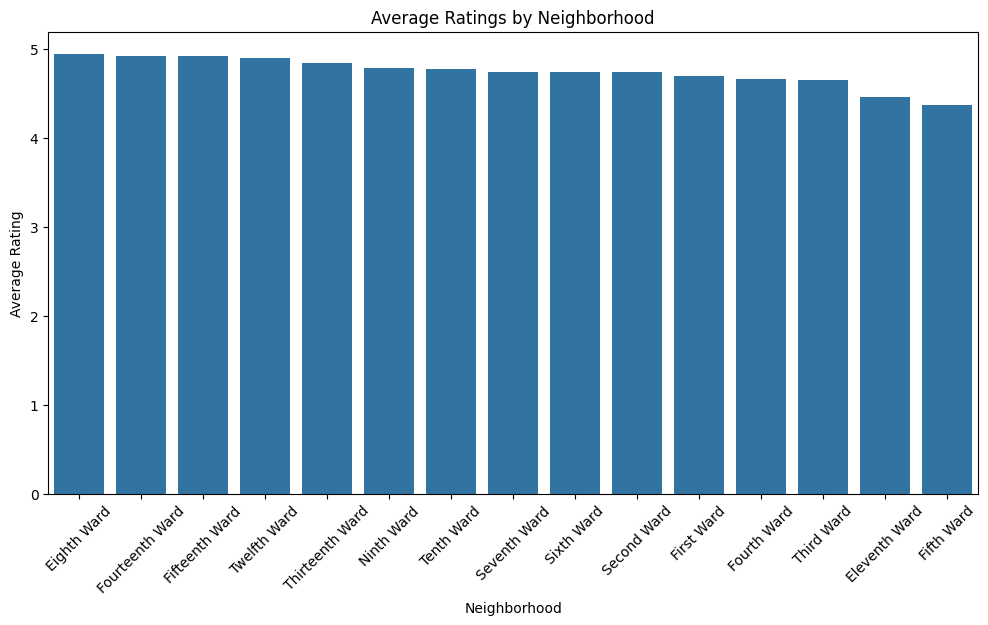

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=ratings_by_neighborhood.index,
    y=ratings_by_neighborhood.values
)

plt.xticks(rotation=45)

plt.title("Average Ratings by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Average Rating")

plt.show()

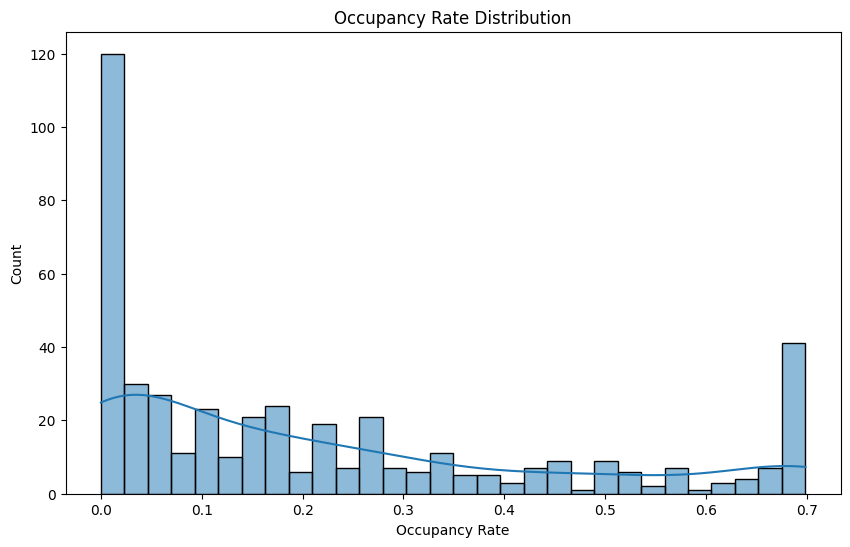

In [20]:
# occupancy distribution
plt.figure(figsize=(10,6))

sns.histplot(
    listings['occupancy_rate'],
    bins=30,
    kde=True
)

plt.title("Occupancy Rate Distribution")
plt.xlabel("Occupancy Rate")

plt.show()

In [21]:
top_occupied = listings.sort_values(by='occupancy_rate',ascending=False)

top_occupied[
    [
        'listing_id',
        'neighborhood',
        'room_type',
        'occupancy_rate',
        'number_of_reviews'
    ]
].head(10)

,listing_id,neighborhood,room_type,occupancy_rate,number_of_reviews
328,1371829070623409671,Sixth Ward,Entire home/apt,0.69863,63
363,1450136720901316807,Second Ward,Entire home/apt,0.69863,48
324,1369127908322228929,Fourth Ward,Entire home/apt,0.69863,51
38,28722270,Second Ward,Entire home/apt,0.69863,735
32,25549565,Sixth Ward,Entire home/apt,0.69863,972
280,1233366548908684664,Sixth Ward,Entire home/apt,0.69863,92
308,1310170283925918533,Eleventh Ward,Private room,0.69863,62
304,1296756366433115082,Eleventh Ward,Private room,0.69863,103
47,33558235,Second Ward,Entire home/apt,0.69863,496
319,1350872245042831459,Fifteenth Ward,Entire home/apt,0.69863,68


In [22]:
room_counts = listings['room_type'].value_counts()

room_counts

room_type
Entire home/apt    339
Private room       114
Name: count, dtype: int64

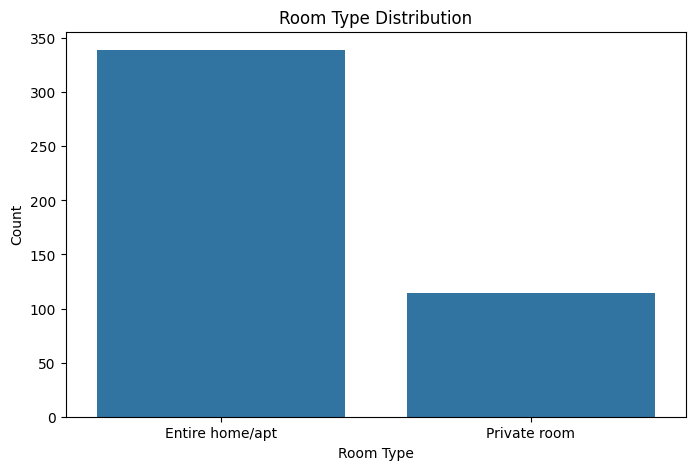

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=room_counts.index,
    y=room_counts.values
)

plt.title("Room Type Distribution")
plt.xlabel("Room Type")
plt.ylabel("Count")

plt.show()

In [24]:
room_occupancy = (
    listings
    .groupby('room_type')['occupancy_rate']
    .mean()
    .sort_values(ascending=False)
)

room_occupancy

room_type
Entire home/apt    0.225910
Private room       0.195025
Name: occupancy_rate, dtype: float64

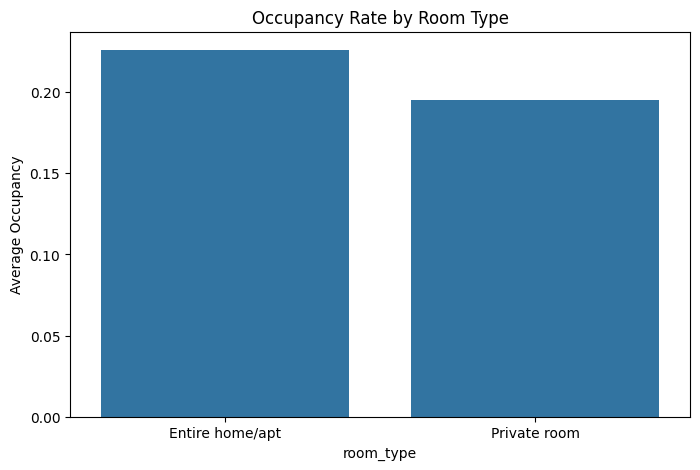

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=room_occupancy.index,
    y=room_occupancy.values
)

plt.title("Occupancy Rate by Room Type")
plt.ylabel("Average Occupancy")

plt.show()

In [26]:
listings['calculated_host_listings_count'].describe()

count    453.000000
mean       7.662252
std        7.994650
min        1.000000
25%        1.000000
50%        5.000000
75%       11.000000
max       30.000000
Name: calculated_host_listings_count, dtype: float64

In [27]:
# top hosts
top_hosts = listings.sort_values(
    by='calculated_host_listings_count',
    ascending=False
)

top_hosts[
    [
        'host_name',
        'neighborhood',
        'calculated_host_listings_count'
    ]
].head(10)

,host_name,neighborhood,calculated_host_listings_count
451,⁨Premier Stay Co.⁩,Eleventh Ward,30
450,⁨Premier Stay Co.⁩,Eleventh Ward,30
430,⁨Premier Stay Co.⁩,Eleventh Ward,30
426,⁨Premier Stay Co.⁩,Eleventh Ward,30
420,⁨Premier Stay Co.⁩,Eleventh Ward,30
419,⁨Premier Stay Co.⁩,Eleventh Ward,30
394,⁨Premier Stay Co.⁩,Eleventh Ward,30
412,⁨Premier Stay Co.⁩,Eleventh Ward,30
393,⁨Premier Stay Co.⁩,Eleventh Ward,30
390,⁨Premier Stay Co.⁩,Fifth Ward,30


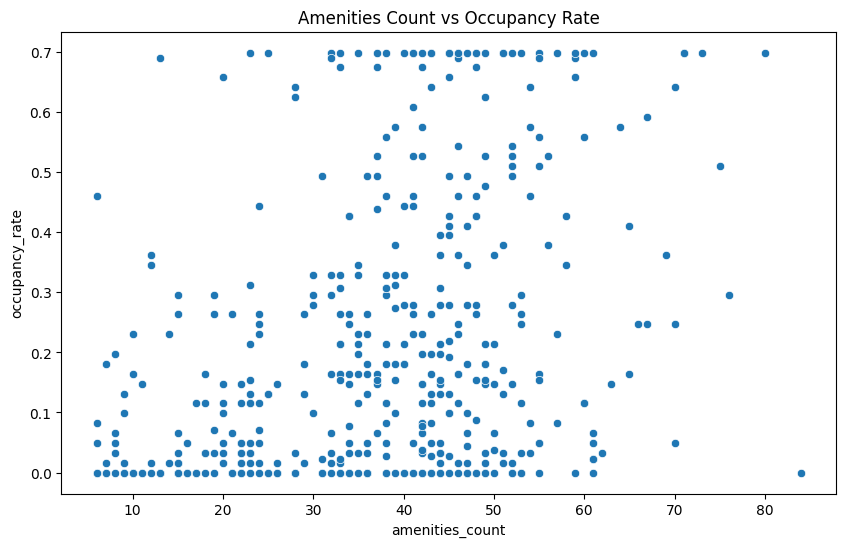

In [28]:
# amenities relation with occupancy
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=listings,
    x='amenities_count',
    y='occupancy_rate'
)

plt.title("Amenities Count vs Occupancy Rate")

plt.show()

In [29]:
numeric_cols = [
    'occupancy_rate',
    'estimated_occupancy_from_calendar',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'amenities_count',
    'calculated_host_listings_count'
]

corr = listings[numeric_cols].corr()

corr

,occupancy_rate,estimated_occupancy_from_calendar,number_of_reviews,reviews_per_month,review_scores_rating,amenities_count,calculated_host_listings_count
occupancy_rate,1.000000,0.115354,0.523164,0.758063,0.234289,0.352943,-0.082496
estimated_occupancy_from_calendar,0.115354,1.000000,0.070713,0.056131,0.235298,0.247714,-0.121812
number_of_reviews,0.523164,0.070713,1.000000,0.686086,0.149785,0.219647,-0.106083
reviews_per_month,0.758063,0.056131,0.686086,1.000000,0.179950,0.232851,-0.119448
review_scores_rating,0.234289,0.235298,0.149785,0.179950,1.000000,0.339129,-0.212562
amenities_count,0.352943,0.247714,0.219647,0.232851,0.339129,1.000000,-0.080969
calculated_host_listings_count,-0.082496,-0.121812,-0.106083,-0.119448,-0.212562,-0.080969,1.000000


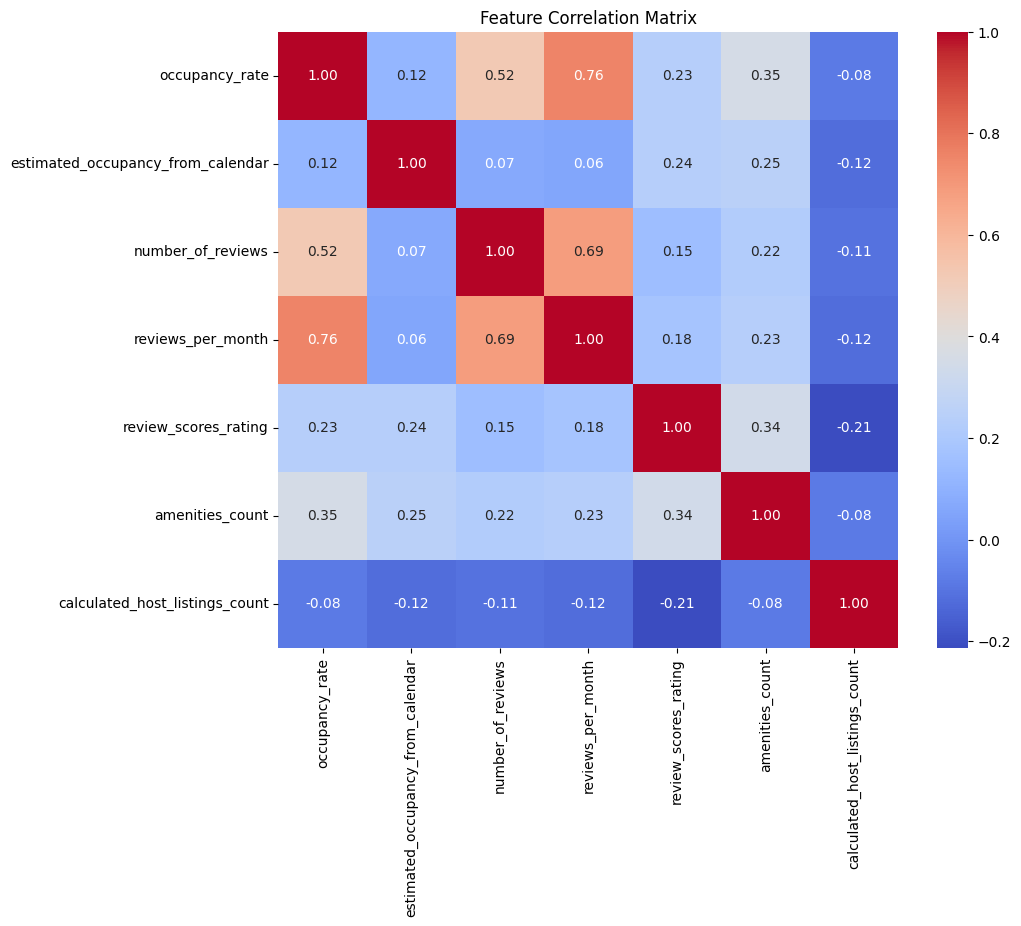

In [31]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Matrix")

plt.show()